In [329]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

## TASKS
Developing a content-based recommender system using the genres and/or descriptions.  
Identifying the main content available on the streaming.  
Network analysis on the cast of the titles.  
Exploratory data analysis to find interesting insights.  

## Loading the dataset

In [330]:
df_title=pd.read_csv('titles.csv')
df_title.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,tm155702,The Wizard of Oz,MOVIE,Young Dorothy finds herself in a magical world...,1939,G,102,"['fantasy', 'family']",['US'],NaN,tt0032138,8.1,389774.0,41.442,7.6
1,tm83648,Citizen Kane,MOVIE,"Newspaper magnate, Charles Foster Kane is take...",1941,PG,119,['drama'],['US'],NaN,tt0033467,8.3,433804.0,14.383,8.0
2,tm77588,Casablanca,MOVIE,"In Casablanca, Morocco in December 1941, a cyn...",1942,PG,102,"['drama', 'romance', 'war']",['US'],NaN,tt0034583,8.5,558849.0,20.087,8.2
3,tm82363,The Big Sleep,MOVIE,Private Investigator Philip Marlowe is hired b...,1946,NaN,116,"['thriller', 'crime']",['US'],NaN,tt0038355,7.9,84494.0,12.911,7.7
4,tm84701,The Maltese Falcon,MOVIE,A private detective takes on a case that invol...,1941,NaN,100,"['thriller', 'romance', 'crime']",['US'],NaN,tt0033870,8.0,156603.0,12.788,7.8


In [331]:
df_title.shape

(3294, 15)

In [332]:
df_title.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3294 entries, 0 to 3293
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    3294 non-null   object 
 1   title                 3294 non-null   object 
 2   type                  3294 non-null   object 
 3   description           3282 non-null   object 
 4   release_year          3294 non-null   int64  
 5   age_certification     2086 non-null   object 
 6   runtime               3294 non-null   int64  
 7   genres                3294 non-null   object 
 8   production_countries  3294 non-null   object 
 9   seasons               756 non-null    float64
 10  imdb_id               2968 non-null   object 
 11  imdb_score            2922 non-null   float64
 12  imdb_votes            2911 non-null   float64
 13  tmdb_popularity       3261 non-null   float64
 14  tmdb_score            3026 non-null   float64
dtypes: float64(5), int64(

In [333]:
df_title.describe()

,release_year,runtime,seasons,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
count,3294.000000,3294.000000,756.000000,2922.000000,2.911000e+03,3261.000000,3026.000000
mean,2001.194293,80.914997,2.998677,6.883949,6.461835e+04,21.105891,6.850099
std,23.542337,38.475347,3.651181,1.059668,1.754617e+05,89.137800,1.081377
min,1901.000000,1.000000,1.000000,1.500000,5.000000e+00,0.050393,1.000000
25%,1995.000000,51.250000,1.000000,6.300000,9.245000e+02,3.450000,6.200000
50%,2010.000000,89.000000,2.000000,7.000000,8.071000e+03,8.561000,6.900000
75%,2018.000000,106.000000,4.000000,7.600000,4.764500e+04,17.711000,7.500000
max,2022.000000,255.000000,52.000000,9.400000,2.555504e+06,4447.894000,10.000000


## Initial Exploration

In [334]:
numerical_features=[feature for feature in df_title.columns if df_title[feature].dtype !='O']
categorical_features=[feature for feature in df_title.columns if df_title[feature].dtype == 'O']
print(f'categorical features:',categorical_features)
print(f'numerical features:',numerical_features)

categorical features: ['id', 'title', 'type', 'description', 'age_certification', 'genres', 'production_countries', 'imdb_id']
numerical features: ['release_year', 'runtime', 'seasons', 'imdb_score', 'imdb_votes', 'tmdb_popularity', 'tmdb_score']


In [335]:
for col in categorical_features:
    print(col)
    print(df_title[col].unique())
    print('-------------')
   
    

id
['tm155702' 'tm83648' 'tm77588' ... 'tm1121489' 'tm1121486' 'tm989132']
-------------
title
['The Wizard of Oz' 'Citizen Kane' 'Casablanca' ...
 'Entre Nos: What She Said' 'Entre Nos: The Winners 2'
 'The Infamous Future']
-------------
type
['MOVIE' 'SHOW']
-------------
description
['Young Dorothy finds herself in a magical world where she makes friends with a lion, a scarecrow and a tin man as they make their way along the yellow brick road to talk with the Wizard and ask for the things they miss most in their lives. The Wicked Witch of the West is the only thing that could stop them.'
 'Newspaper magnate, Charles Foster Kane is taken from his mother as a boy and made the ward of a rich industrialist. As a result, every well-meaning, tyrannical or self-destructive move he makes for the rest of his life appears in some way to be a reaction to that deeply wounding event.'
 'In Casablanca, Morocco in December 1941, a cynical American expatriate meets a former lover, with unforeseen 

In [336]:
df_title['genres'].unique()

array(["['fantasy', 'family']", "['drama']",
       "['drama', 'romance', 'war']", ...,
       "['fantasy', 'family', 'animation']",
       "['family', 'fantasy', 'animation', 'comedy']",
       "['romance', 'music']"], dtype=object)

## Data cleaning

In [337]:
df_title.isnull().sum()

id                         0
title                      0
type                       0
description               12
release_year               0
age_certification       1208
runtime                    0
genres                     0
production_countries       0
seasons                 2538
imdb_id                  326
imdb_score               372
imdb_votes               383
tmdb_popularity           33
tmdb_score               268
dtype: int64

In [338]:
df_title.shape

(3294, 15)

In [339]:
df_title['seasons']=df_title['seasons'].fillna(0)

In [340]:
df_title.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,tm155702,The Wizard of Oz,MOVIE,Young Dorothy finds herself in a magical world...,1939,G,102,"['fantasy', 'family']",['US'],0.0,tt0032138,8.1,389774.0,41.442,7.6
1,tm83648,Citizen Kane,MOVIE,"Newspaper magnate, Charles Foster Kane is take...",1941,PG,119,['drama'],['US'],0.0,tt0033467,8.3,433804.0,14.383,8.0
2,tm77588,Casablanca,MOVIE,"In Casablanca, Morocco in December 1941, a cyn...",1942,PG,102,"['drama', 'romance', 'war']",['US'],0.0,tt0034583,8.5,558849.0,20.087,8.2
3,tm82363,The Big Sleep,MOVIE,Private Investigator Philip Marlowe is hired b...,1946,NaN,116,"['thriller', 'crime']",['US'],0.0,tt0038355,7.9,84494.0,12.911,7.7
4,tm84701,The Maltese Falcon,MOVIE,A private detective takes on a case that invol...,1941,NaN,100,"['thriller', 'romance', 'crime']",['US'],0.0,tt0033870,8.0,156603.0,12.788,7.8


In [341]:
df_title['age_certification']=df_title['age_certification'].fillna('Unknown')

In [342]:
df_title.dropna(subset=['imdb_id'], inplace=True)

In [343]:
df_title.isnull().sum()

id                        0
title                     0
type                      0
description               5
release_year              0
age_certification         0
runtime                   0
genres                    0
production_countries      0
seasons                   0
imdb_id                   0
imdb_score               46
imdb_votes               57
tmdb_popularity          31
tmdb_score              187
dtype: int64

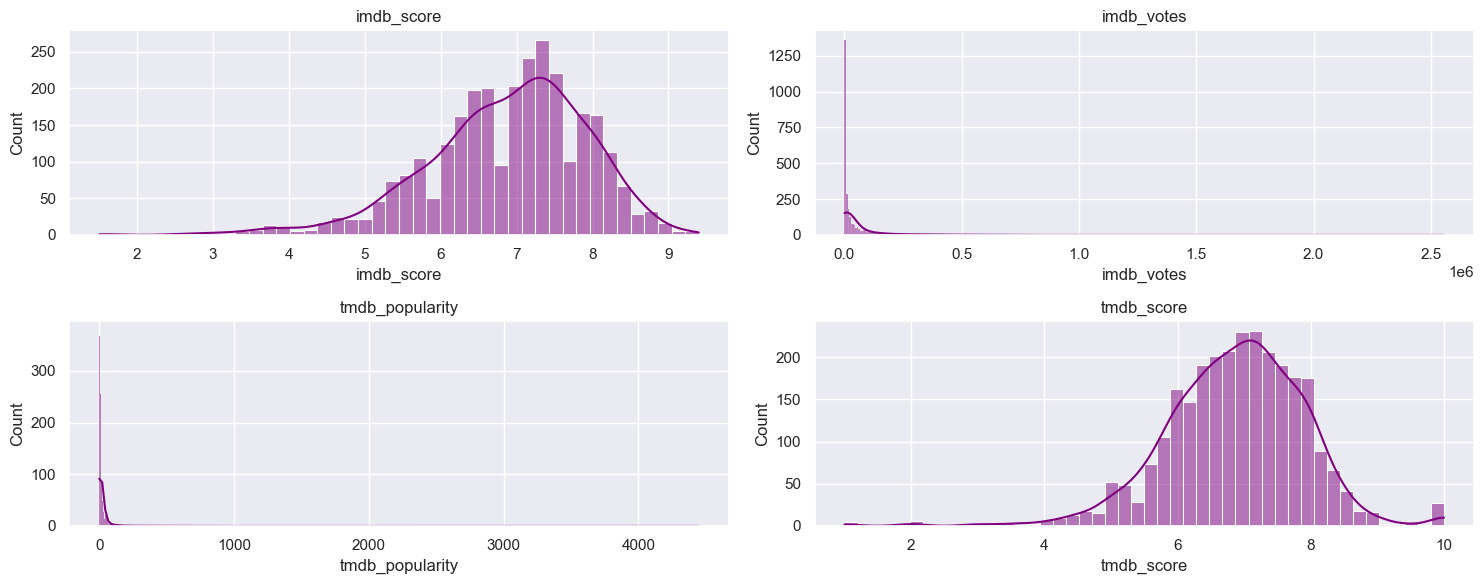

In [344]:
#Normally distributed-use mean
#skewed or has outliers-median
#imbd_score-left skewed
#imdb_vostes-rightskewed
#tmdb_popularity-right skewed
#tmdb_score-left skewed
#Use median imputation to handle missing values for all the features above.
plt.figure(figsize=(15,6))
features=['imdb_score','imdb_votes','tmdb_popularity','tmdb_score']
for i in range(0,len(features)):
    plt.subplot(2,2,i+1)
    sns.histplot(df_title[features[i]],kde=True,color='purple')
    plt.title(features[i])
plt.tight_layout()
plt.show()

In [345]:
df_title['imdb_score']=df_title['imdb_score'].fillna(df_title['imdb_score'].median())
df_title['imdb_votes']=df_title['imdb_votes'].fillna(df_title['imdb_votes'].median())
df_title['tmdb_score']=df_title['tmdb_score'].fillna(df_title['tmdb_score'].median())
df_title['tmdb_popularity']=df_title['tmdb_popularity'].fillna(df_title['tmdb_popularity'].median())




In [346]:
df_title['description']=df_title['description'].fillna('None')

In [347]:
df_title.isnull().sum()

id                      0
title                   0
type                    0
description             0
release_year            0
age_certification       0
runtime                 0
genres                  0
production_countries    0
seasons                 0
imdb_id                 0
imdb_score              0
imdb_votes              0
tmdb_popularity         0
tmdb_score              0
dtype: int64

Checking and handling duplicates


In [348]:
df_title[df_title.duplicated()]

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score


In [349]:
df_title.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2968 entries, 0 to 3293
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    2968 non-null   object 
 1   title                 2968 non-null   object 
 2   type                  2968 non-null   object 
 3   description           2968 non-null   object 
 4   release_year          2968 non-null   int64  
 5   age_certification     2968 non-null   object 
 6   runtime               2968 non-null   int64  
 7   genres                2968 non-null   object 
 8   production_countries  2968 non-null   object 
 9   seasons               2968 non-null   float64
 10  imdb_id               2968 non-null   object 
 11  imdb_score            2968 non-null   float64
 12  imdb_votes            2968 non-null   float64
 13  tmdb_popularity       2968 non-null   float64
 14  tmdb_score            2968 non-null   float64
dtypes: float64(5), int64(2), o

In [350]:
df_title["genres"] = (
    df_title["genres"]
    .str.strip("[]")
    .str.replace("'", "", regex=False)
)

df_title["production_countries"] = (
    df_title["production_countries"]
    .str.strip("[]")
    .str.replace("'", "", regex=False)
)

In [351]:
df_title.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,tm155702,The Wizard of Oz,MOVIE,Young Dorothy finds herself in a magical world...,1939,G,102,"fantasy, family",US,0.0,tt0032138,8.1,389774.0,41.442,7.6
1,tm83648,Citizen Kane,MOVIE,"Newspaper magnate, Charles Foster Kane is take...",1941,PG,119,drama,US,0.0,tt0033467,8.3,433804.0,14.383,8.0
2,tm77588,Casablanca,MOVIE,"In Casablanca, Morocco in December 1941, a cyn...",1942,PG,102,"drama, romance, war",US,0.0,tt0034583,8.5,558849.0,20.087,8.2
3,tm82363,The Big Sleep,MOVIE,Private Investigator Philip Marlowe is hired b...,1946,Unknown,116,"thriller, crime",US,0.0,tt0038355,7.9,84494.0,12.911,7.7
4,tm84701,The Maltese Falcon,MOVIE,A private detective takes on a case that invol...,1941,Unknown,100,"thriller, romance, crime",US,0.0,tt0033870,8.0,156603.0,12.788,7.8


In [352]:
#Remove extra spaces.
df_title['production_countries']=df_title['production_countries'].str.replace(' ','')

In [353]:
df_title['production_countries'].unique()

array(['US', 'JP', 'GB', 'DE', 'IT', 'FR', 'SE', 'FR,DE', 'SU', 'GB,CA',
       'FR,US', 'IT,US', 'IT,XG,FR,DE', 'CH', 'DK', '', 'US,GB', 'GB,US',
       'CA', 'XC,FR', 'IT,FR', 'FR,IT', 'IT,DZ', 'AU', 'DE,IR,FR',
       'FR,BE', 'XC', 'IN', 'ES,CH', 'DZ,FR', 'BR,FR,IT', 'DE,SE,FR',
       'PL', 'SE,FR', 'FR,SN', 'JP,US', 'BE,FR,DE', 'IN,US,FR',
       'ES,CH,FR', 'FR,SU', 'SN', 'US,HK', 'MX', 'ES,US', 'AT', 'NO',
       'HK,US', 'US,MX', 'US,ES,GB,IT', 'CA,US', 'FR,GB,DE', 'HK',
       'US,CA', 'US,CA,IL', 'US,BE', 'US,NL', 'FR,IT,GB,CN', 'GB,US,IE',
       'ES', 'SE,DE,FR', 'US,AU', 'FR,DE,PL', 'DE,US', 'DE,FR,IT',
       'MX,US', 'FR,CH', 'US,DE', 'GB,NZ,AU', 'AR', 'CA,IL', 'DE,FR',
       'XX', 'KR', 'CN,HK', 'JP,US,DE', 'FR,US,CA', 'US,GB,JP', 'US,JP',
       'JP,GB,IE', 'BE', 'JP,AR,HK', 'FR,GB', 'NZ,GB,US,DK,FR',
       'FR,PL,CH', 'GB,US,DE,JP,NZ', 'JP,GB,US,DE',
       'NL,NO,ES,SE,GB,DK,FR,IS', 'GB,US,FR,IT,JP', 'FR,JP,GB,US,DE',
       'PL,FR', 'FR,IR', 'AU,US', 'AT,CH', 'SE

In [354]:
#Handling outliers
numerical_features

['release_year',
 'runtime',
 'seasons',
 'imdb_score',
 'imdb_votes',
 'tmdb_popularity',
 'tmdb_score']

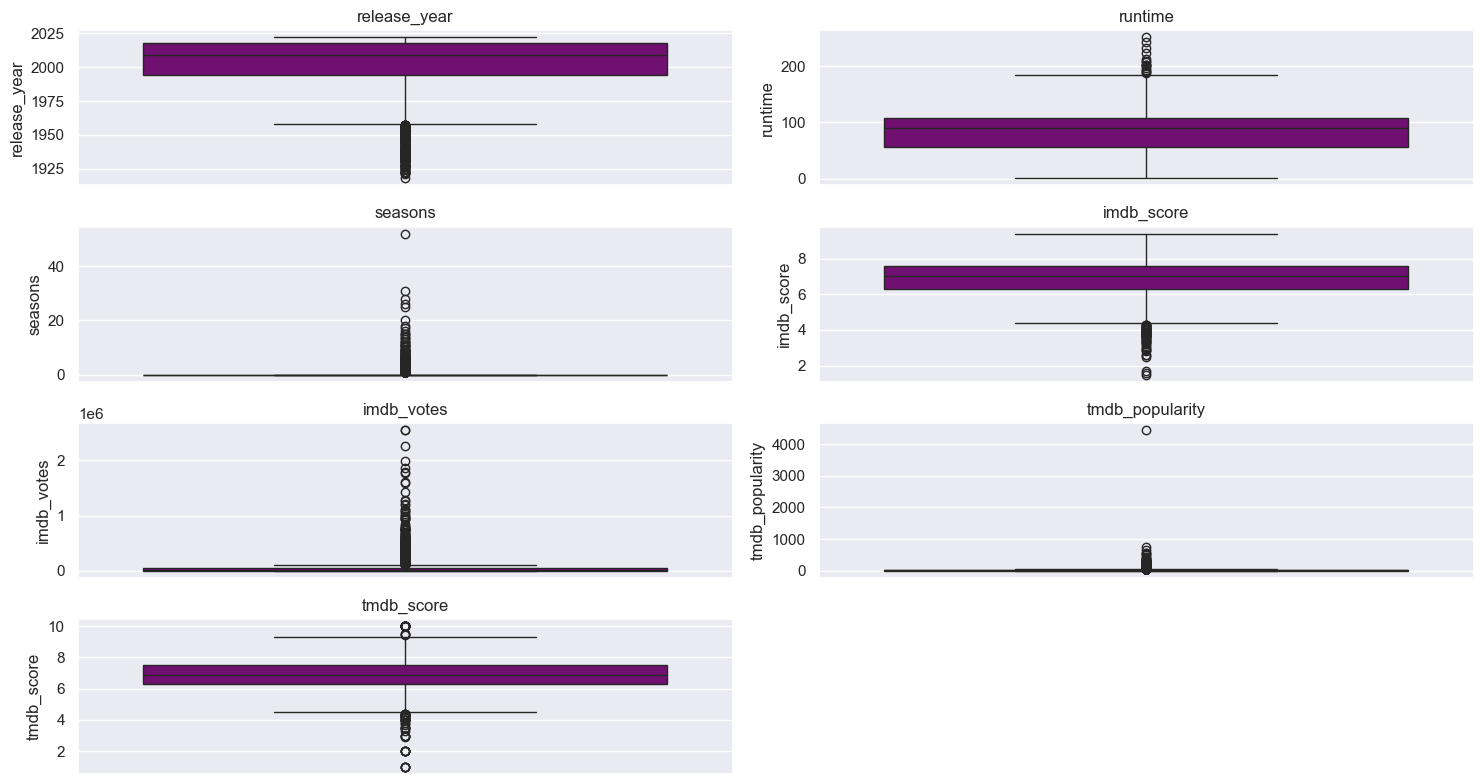

In [355]:

plt.figure(figsize=(15,8))
for i in range(0,len(numerical_features)):
    plt.subplot(4, 2, i+1)
    sns.boxplot(y=df_title[numerical_features[i]],color='purple')
    plt.title(numerical_features[i])
plt.tight_layout()
plt.show()

Outlier analysis was performed using boxplots. Extreme values were observed in tmdb_popularity and imdb_votes feature; 
however,these values represent genuine differences in movie popularity and were retained

In [356]:
df_credits=pd.read_csv('credits.csv')
df_credits.head()

,person_id,id,name,character,role
0,60017,tm155702,Judy Garland,Dorothy Gale,ACTOR
1,53496,tm155702,Ray Bolger,Hunk / Scarecrow,ACTOR
2,79549,tm155702,Jack Haley,Hickory / Tin Man,ACTOR
3,79548,tm155702,Bert Lahr,Zeke / Cowardly Lion,ACTOR
4,60995,tm155702,Margaret Hamilton,Elmira Gulch / Wicked Witch of the West,ACTOR


In [357]:
df_credits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66393 entries, 0 to 66392
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   person_id  66393 non-null  int64 
 1   id         66393 non-null  object
 2   name       66393 non-null  object
 3   character  61888 non-null  object
 4   role       66393 non-null  object
dtypes: int64(1), object(4)
memory usage: 2.5+ MB


In [358]:
df_credits.describe()

,person_id
count,6.639300e+04
mean,3.479124e+05
std,5.539732e+05
min,7.000000e+00
25%,1.754400e+04
50%,7.037900e+04
75%,4.835320e+05
max,2.369354e+06


In [359]:
df_credits.shape

(66393, 5)

## Data cleaning

In [360]:
df_credits.isnull().sum()

person_id       0
id              0
name            0
character    4505
role            0
dtype: int64

In [361]:
df_credits.dropna(subset='character',inplace=True)

In [362]:
df_credits.isnull().sum()

person_id    0
id           0
name         0
character    0
role         0
dtype: int64

In [363]:
df_credits['character']

0                                   Dorothy Gale
1                               Hunk / Scarecrow
2                              Hickory / Tin Man
3                           Zeke / Cowardly Lion
4        Elmira Gulch / Wicked Witch of the West
                          ...                   
66386                          Oficial Contreras
66387                          Oficial Jaramillo
66388                                      Marta
66389                                    Claudia
66390                                       Nora
Name: character, Length: 61888, dtype: object

In [364]:
df=pd.merge(df_title,df_credits,on='id',how='inner')

In [365]:
df.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id,name,character,role
0,tm155702,The Wizard of Oz,MOVIE,Young Dorothy finds herself in a magical world...,1939,G,102,"fantasy, family",US,0.0,tt0032138,8.1,389774.0,41.442,7.6,60017,Judy Garland,Dorothy Gale,ACTOR
1,tm155702,The Wizard of Oz,MOVIE,Young Dorothy finds herself in a magical world...,1939,G,102,"fantasy, family",US,0.0,tt0032138,8.1,389774.0,41.442,7.6,53496,Ray Bolger,Hunk / Scarecrow,ACTOR
2,tm155702,The Wizard of Oz,MOVIE,Young Dorothy finds herself in a magical world...,1939,G,102,"fantasy, family",US,0.0,tt0032138,8.1,389774.0,41.442,7.6,79549,Jack Haley,Hickory / Tin Man,ACTOR
3,tm155702,The Wizard of Oz,MOVIE,Young Dorothy finds herself in a magical world...,1939,G,102,"fantasy, family",US,0.0,tt0032138,8.1,389774.0,41.442,7.6,79548,Bert Lahr,Zeke / Cowardly Lion,ACTOR
4,tm155702,The Wizard of Oz,MOVIE,Young Dorothy finds herself in a magical world...,1939,G,102,"fantasy, family",US,0.0,tt0032138,8.1,389774.0,41.442,7.6,60995,Margaret Hamilton,Elmira Gulch / Wicked Witch of the West,ACTOR


In [366]:
df.tail()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id,name,character,role
59390,tm1067128,Algo Azul,MOVIE,Romantic comedy...coming soon.,2021,Unknown,90,comedy,PA,0.0,tt9257620,5.9,50.0,1.4,2.0,2305720,Hugo Victor Rodriguez,Oficial Contreras,ACTOR
59391,tm1067128,Algo Azul,MOVIE,Romantic comedy...coming soon.,2021,Unknown,90,comedy,PA,0.0,tt9257620,5.9,50.0,1.4,2.0,2305322,Juan Carlos Avendaño,Oficial Jaramillo,ACTOR
59392,tm1067128,Algo Azul,MOVIE,Romantic comedy...coming soon.,2021,Unknown,90,comedy,PA,0.0,tt9257620,5.9,50.0,1.4,2.0,1224011,Stella Lauri,Marta,ACTOR
59393,tm1067128,Algo Azul,MOVIE,Romantic comedy...coming soon.,2021,Unknown,90,comedy,PA,0.0,tt9257620,5.9,50.0,1.4,2.0,2305342,Fabiola Sánchez,Claudia,ACTOR
59394,tm1067128,Algo Azul,MOVIE,Romantic comedy...coming soon.,2021,Unknown,90,comedy,PA,0.0,tt9257620,5.9,50.0,1.4,2.0,1245864,Ash Olivera,Nora,ACTOR


In [367]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59395 entries, 0 to 59394
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    59395 non-null  object 
 1   title                 59395 non-null  object 
 2   type                  59395 non-null  object 
 3   description           59395 non-null  object 
 4   release_year          59395 non-null  int64  
 5   age_certification     59395 non-null  object 
 6   runtime               59395 non-null  int64  
 7   genres                59395 non-null  object 
 8   production_countries  59395 non-null  object 
 9   seasons               59395 non-null  float64
 10  imdb_id               59395 non-null  object 
 11  imdb_score            59395 non-null  float64
 12  imdb_votes            59395 non-null  float64
 13  tmdb_popularity       59395 non-null  float64
 14  tmdb_score            59395 non-null  float64
 15  person_id          

## EDA

## Qts 
1.How has the number of movies and TV shows released changed over the years?  
2.What is the distribution of content types (Movies vs TV Shows)?  
3.What is the distribution of age certification categories?  
4.What is the most common genre?  
5.Which countries produced the most movies and TV shows?  
6.Is there a correlation between IMDb votes and IMDb score?  
7.How has the average IMDb score changed over the years?  
8.Which genres have the highest average IMDb scores?  
9.Do movies or TV shows have higher IMDb scores?  
10.Which movies or TV shows have the highest IMDb scores?  
11.Does runtime affect IMDb score?  
12.Which actors have appeared in the most titles?  
13.Which titles have the highest IMDb votes?  
14.Which titles have the highest TMDB popularity?

In [368]:
movies = df_title[df_title['type'] == 'MOVIE']['title'].count()
shows = df_title[df_title['type'] == 'SHOW']['title'].count()

print("MOVIES:", movies)
print("SHOWS:", shows)

MOVIES: 2266
SHOWS: 702


There are 2266 movies and 702 shows in our dataset

## Univariate analysis

In [369]:
df_title.head(2)

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,tm155702,The Wizard of Oz,MOVIE,Young Dorothy finds herself in a magical world...,1939,G,102,"fantasy, family",US,0.0,tt0032138,8.1,389774.0,41.442,7.6
1,tm83648,Citizen Kane,MOVIE,"Newspaper magnate, Charles Foster Kane is take...",1941,PG,119,drama,US,0.0,tt0033467,8.3,433804.0,14.383,8.0


In [370]:
sns.set_theme()
hbo_max_colors = ["#002BE7", "#991EEB", "#9E86FF"]
hbo_gradient = sns.blend_palette(hbo_max_colors, n_colors=20, as_cmap=True)
hbo_max_colors = sns.color_palette(["#121124",  # 1. Darkest Shadow Purple
    "#2E1154",  # 2. Rich Dark Violet
    "#461280",  # 3. Deep Grape Purple
    "#5822B4",  # 4. Classic HBO Purple
    "#7B1FA2",  # 5. Neon Amethyst 
    "#991EEB",  # 6. Vibrant Bright Purple
    "#002BE7",  # 7. Electric Neon Blue
    "#00A2FF",  # 8. Cyan Sign Glow
    "#9E86FF",  # 9. Heliotrope Lavender
    "#E91E63",  # 10. Vivid Hot Pink
    "#FF5722",  # 11. Fiery Orange-Red
    "#FF9100" ])


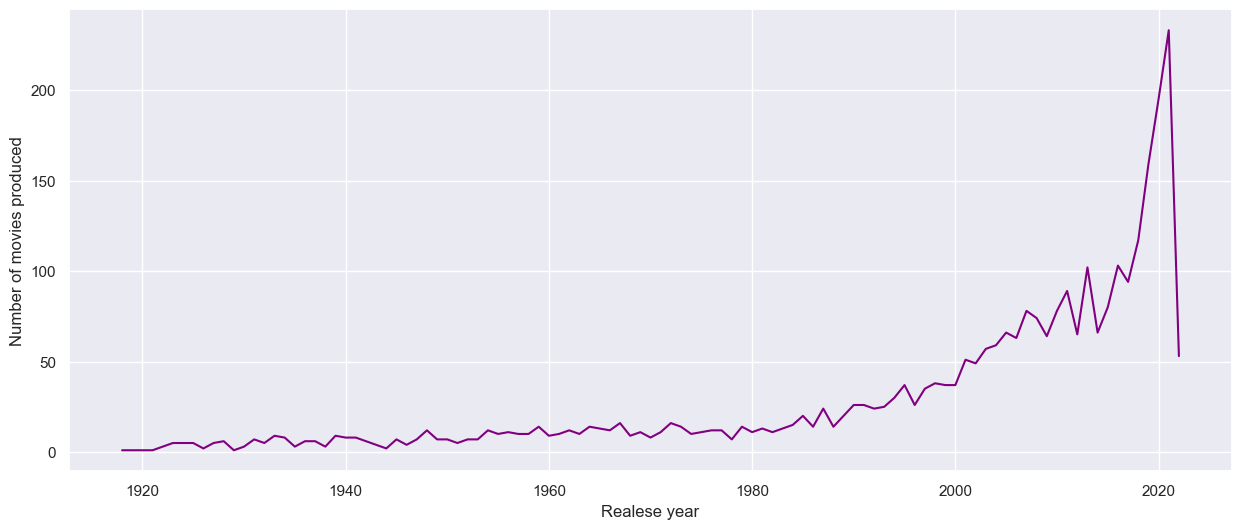

In [371]:
#1.How has the number of movies and TV shows released changed over the years?
plt.figure(figsize=(15,6))
year_count=df_title['release_year'].value_counts()
sns.lineplot(x=year_count.index,y=year_count,color='purple')
plt.xlabel("Realese year")
plt.ylabel("Number of movies produced")
plt.show()


Observations:  
1.The number of movies and TV shows released increased steadily between 1980 and 2021.  
2.2021 recorded the highest number of movie and TV show releases in the dataset.  
Conclusions:  
The HBO Max dataset indicates a significant growth in movies/Tv shows production over the years, with the most substantial output occurring in 2021. This suggests that the platformis largely composed of recent releases, reflecting the industry's increasing investment in producing and distributing streaming content during the 21st century.


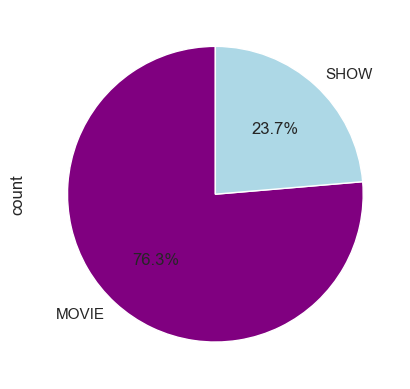

In [372]:
# 2.What is the distribution of content types (Movies vs TV Shows)?
colors=['purple','lightblue']
type_film=df_title['type'].value_counts().plot(kind='pie',autopct='%1.1f%%',colors=colors,startangle=90)
plt.show()



Observations:  
1.Movies make up a large propotion of the dataset than TV Shows.  
Conclusion:   
The dataset suggests that HBO Max offers a great number of movies than TV Shows,which shows a greater emphasis on movie production.



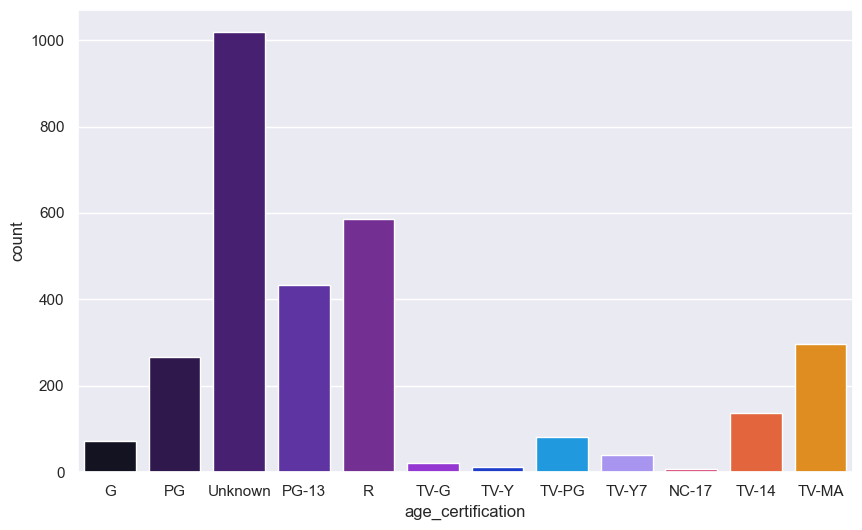

In [373]:
# 3.What is the distribution of age certification categories?
plt.figure(figsize=(10,6))
sns.countplot(data=df_title,x="age_certification",hue='age_certification',palette=hbo_max_colors)
plt.show()

Observation:  
1.Titles with missing (unknown) age certifications make up the largest proportion of the dataset.  
2.Among the specified age certifications, R is the most common, followed by PG-13.  
Conclusion:  
A larger portion of the dataset lack age_certification information.The categories available with age ertification data R and PG-13 are the most common ratings.

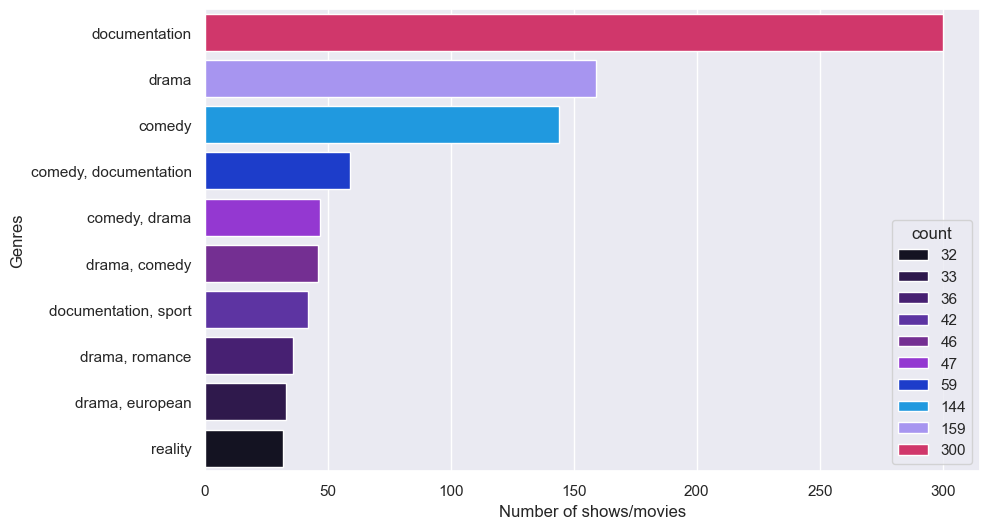

In [374]:
#4.What is the most common genre?
plt.figure(figsize=(10,6))
genre=df_title['genres'].value_counts().head(10)
sns.barplot(x=genre,y=genre.index,hue=genre,palette=hbo_max_colors)
plt.xlabel('Number of shows/movies')
plt.ylabel('Genres')
plt.show()

Observation:  
1.Documentation is the most common genre in the dataset,followed by Drama and Comedy.  
Conclusion:  
The HBO Max dataset is dominated by documentary content, with drama and comedy also representing a substantial portion.


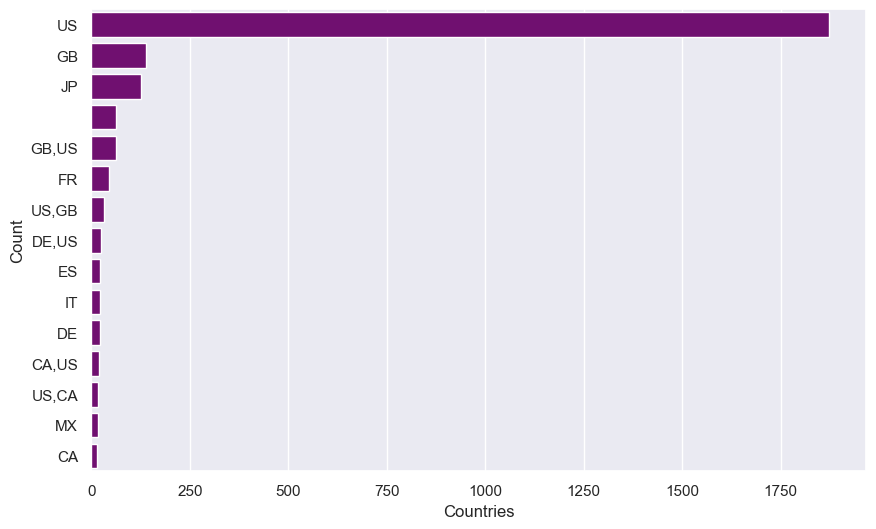

In [375]:
# 5.Which countries produced the most movies and TV shows?
plt.figure(figsize=(10,6))
countries=df_title.explode('production_countries')['production_countries'].value_counts().head(15)
sns.barplot(y=countries.index,x=countries,color='purple')
plt.xlabel("Countries")
plt.ylabel("Count")
plt.show()

Observation:  
1.The US produced the largest number of movies and TV Shows in the dataset.  
Conclusion:  
The dataset indicates that the United States is the dominant producer of movies and TV shows, contributing a significantly larger share of content than any other country.

## Bivariate Analysis

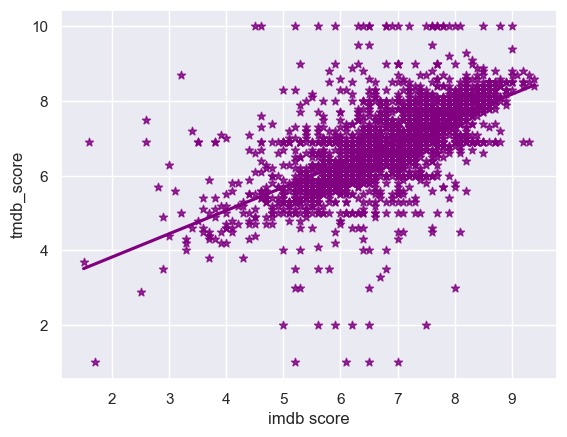

In [376]:
#6.Is there a correlation between IMDb votes and IMDb score?
sns.regplot(data=df_title,x="imdb_score",y='tmdb_score',ci=None,color='purple',marker='*')
plt.xlabel("imdb score")
plt.ylabel("tmdb_score")
plt.show()

Observation:  
1.
IMDb scores and TMDb scores tend to increase and decrease together, indicating that they move in the same direction.  
Conclusion:  
There is a positive correlation between IMDB scores and TMDB scores.This indicates that highly rated titles in IMDB also recieve high ratings in TMDB.

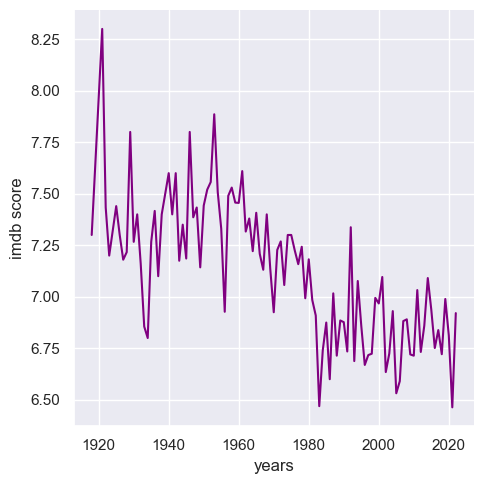

In [377]:
#7.How has the average IMDb score changed over the years?  
imdb_trend=df_title.groupby("release_year")['imdb_score'].mean()
sns.relplot(kind='line',x=imdb_trend.index,y=imdb_trend,color='purple')
plt.xlabel("years")
plt.ylabel( "imdb score")
plt.show()

Obervations:  
1.There is a decline in the average IMDB score over the years.  
Conclusion:  
Average IMDb ratings have decreased over time, suggesting that more recently released titles tend to receive  lower IMDb scores than older titles in this dataset.


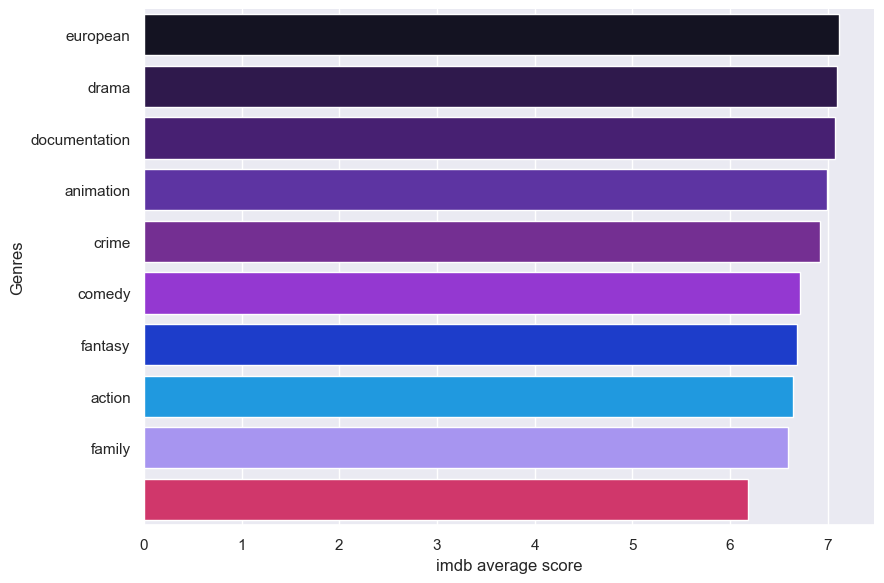

In [378]:
# 8.Which genres have the highest average IMDb scores?
df_title['genres']=df_title['genres'].str.split(',')
genre_exp=df_title.explode('genres',ignore_index=True)
genre_exp['genres'] = genre_exp['genres'].str.strip()
imdb_avg=genre_exp.groupby('genres')['imdb_score'].mean().head(10).sort_values(ascending=False)
sns.catplot(kind='bar',x=imdb_avg.values,y=imdb_avg.index,hue=imdb_avg.index,palette=hbo_max_colors,height=6,aspect=1.5)
plt.xlabel("imdb average score")
plt.ylabel("Genres")
plt.tight_layout()
plt.show()

Observation:  
The European genre has the highest average IMDb score, followed closely by Drama and Documentation.  
Conclusion:  
European titles tend to receive the highest average IMDb ratings in the dataset, with Drama and Documentation also performing well. This suggests that these genres are generally more highly rated by viewers than other genres.

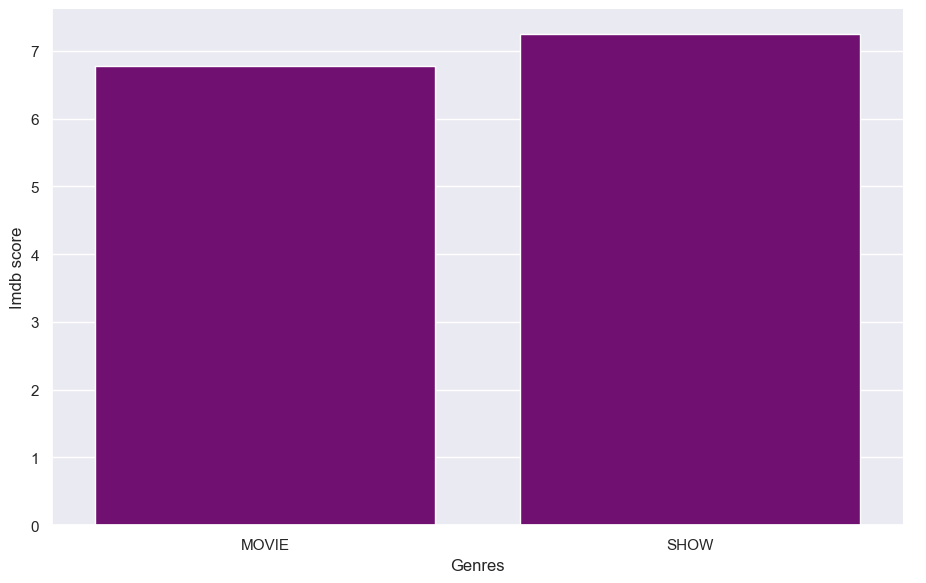

In [379]:
# 9.Do movies or TV shows have higher IMDb scores?  
type_imdb=df_title.groupby('type')['imdb_score'].mean()
sns.catplot(kind='bar',x=type_imdb.index,y=type_imdb.values,color='purple',height=6,aspect=1.5)
plt.xlabel("Genres")
plt.ylabel('Imdb score')
plt.show()

Observation:  
1.TV Shows have a higher average IMDB score than Movies.  
Conclusion:    
TV Shows recieve higher ratings than Movies in the dataset.This suggests that TV shows are more favourably rated by viewers.

<Figure size 1500x800 with 0 Axes>

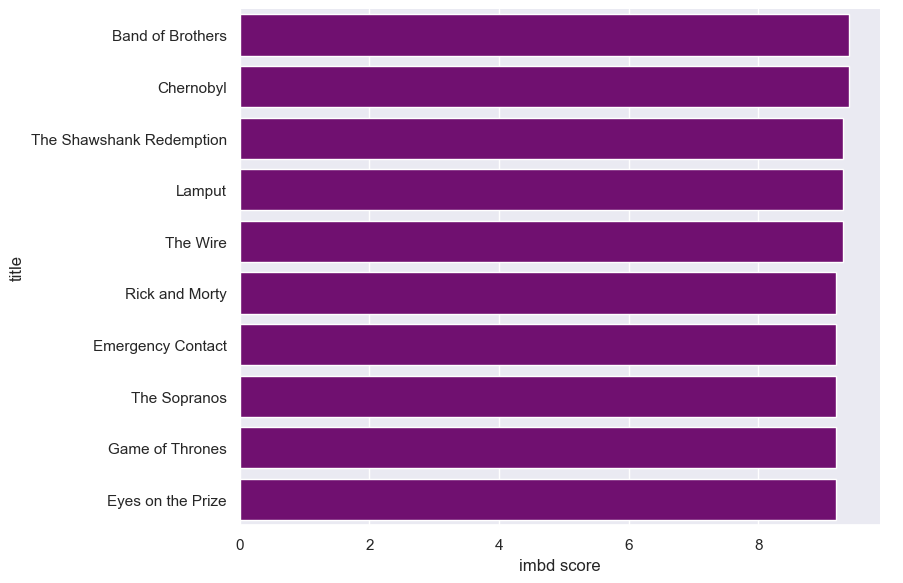

In [380]:
# 10.Which movies or TV shows have the highest IMDb scores? 
title_imdb = df_title[['title', 'imdb_score']].sort_values(by='imdb_score', ascending=False).head(10)
hue_title=df_title['type']
plt.figure(figsize=(15,8))
sns.catplot(kind='bar',data=title_imdb,x='imdb_score',y='title',color='purple',height=6,aspect=1.5)
plt.xlabel("imbd score")
plt.ylabel("title")
plt.show()

Observation:  
Band of brothers  has the highest IMDB score in the datatset ,followed by Chernobyl and The Shawshank Redemption.  
Conclusion:  
These titles are highly rated in the dataset, indicating that they have received exceptional viewers' ratings on IMDb and are among the most critically acclaimed titles


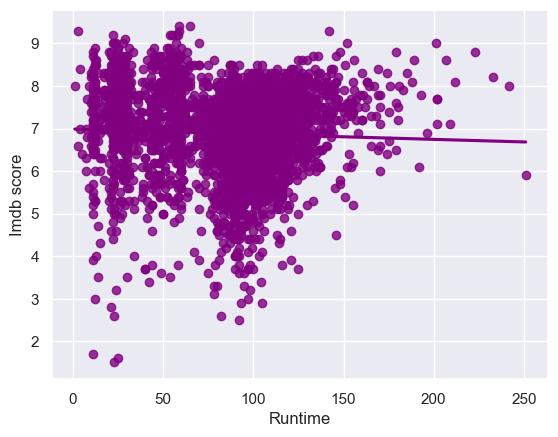

In [381]:
# 11.Does runtime affect IMDb score?
sns.regplot(data=df_title,x='runtime',y='imdb_score',ci=None,color='purple')
plt.xlabel('Runtime')
plt.ylabel('Imdb score')
plt.show()

Observation:  
There is no clear pattern suggesting that runtime affects IMDB scores in the dataset.   
Conclusion:    
There is little to no correlation between runtime and IMDb score, indicating that a title's runtime does not appear to have a significant influence on its IMDb rating.

In [382]:
df.head(1)

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id,name,character,role
0,tm155702,The Wizard of Oz,MOVIE,Young Dorothy finds herself in a magical world...,1939,G,102,"fantasy, family",US,0.0,tt0032138,8.1,389774.0,41.442,7.6,60017,Judy Garland,Dorothy Gale,ACTOR


In [383]:
top_actors=df.groupby('name')['title'].count().sort_values(ascending=False).head(10)
top_actors

name
Frank Welker                26
Kevin Michael Richardson    24
Tara Strong                 23
Grey DeLisle                23
Samuel L. Jackson           21
Tom Kenny                   20
Fred Tatasciore             19
Liev Schreiber              18
Dee Bradley Baker           18
Matt Damon                  18
Name: title, dtype: int64

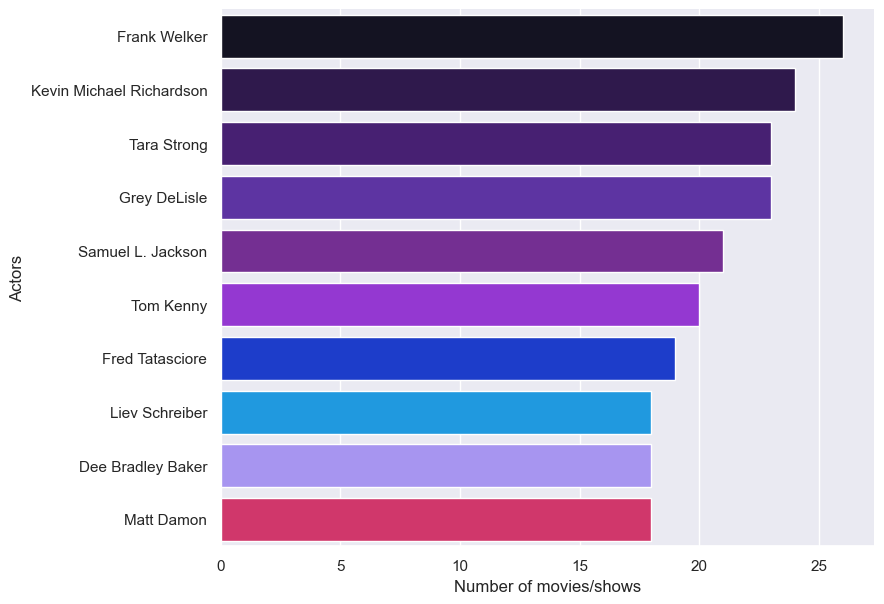

In [384]:
# 12.Which actors have appeared in the most titles?
top_actors=df.groupby('name')['title'].count().sort_values(ascending=False).head(10)
sns.catplot(kind='bar',x=top_actors.values,y=top_actors.index,hue=top_actors.index,palette=hbo_max_colors,height=6,aspect=1.5)
plt.xlabel('Number of movies/shows')
plt.ylabel('Actors')
plt.show()

Observation:  
Frank Welker has appeared in the highest number of Movies/TV Shows in the dataset, followed closely by Kevin Michael Richardson and Tara Strong.  
Conclusion:    
Frank Welker is the most prolific actor in the dataset, with Kevin Michael Richardson and Tara Strong also having appeared in a large number of titles.This suggests that these actors have had extensive and consistent careers across film and television.

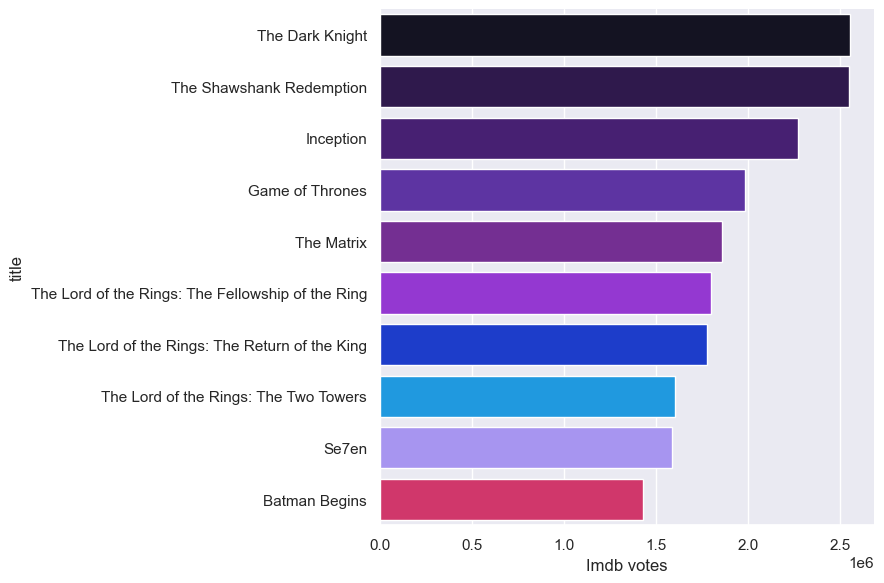

In [385]:
# 13.Which titles have the highest IMDb votes?
title_votes=df_title[['title','imdb_votes']].sort_values(by='imdb_votes',ascending=False).head(10)
sns.catplot(kind='bar',data=title_votes,x='imdb_votes',y='title',hue='title',palette=hbo_max_colors,height=6,aspect=1.5)
plt.xlabel('Imdb votes')
plt.ylabel('title')
plt.show()

Observation:  
The Dark Knight has the highest number of IMDB votes in the dataset,followed closely by The ShawSHank Redemption and Inception.  
Conclusion:  
These titles are the most widely rated by IMDb users, indicating that they have attracted a large audience and generated significant viewer engagement.


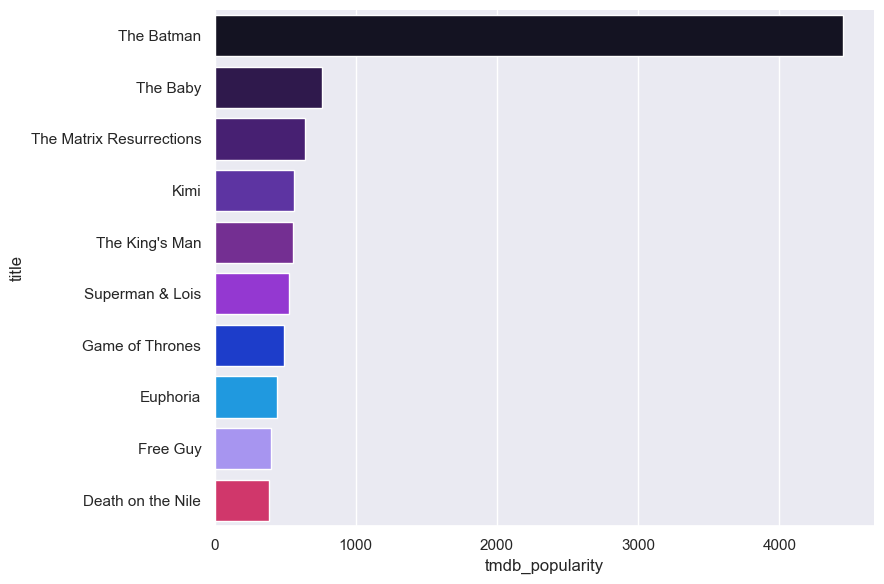

In [386]:
# 14.Which titles have the highest TMDB popularity?
title_tmdb=df_title[['title','tmdb_popularity']].sort_values(by='tmdb_popularity',ascending=False).head(10)
sns.catplot(kind='bar',data=title_tmdb,x='tmdb_popularity',y='title',hue='title',palette=hbo_max_colors,height=6,aspect=1.5)
plt.xlabel('tmdb_popularity')
plt.ylabel('title')
plt.show()

Observation:  
The Batman has the highest TMDb popularity score in the dataset, followed by The Baby and The Matrix Resurrections.  
Conclusion:  
These titles are the most popular on TMDb within the dataset, indicating that they generated high levels of audience interest and engagement on the platform.

## Multivariate analysis

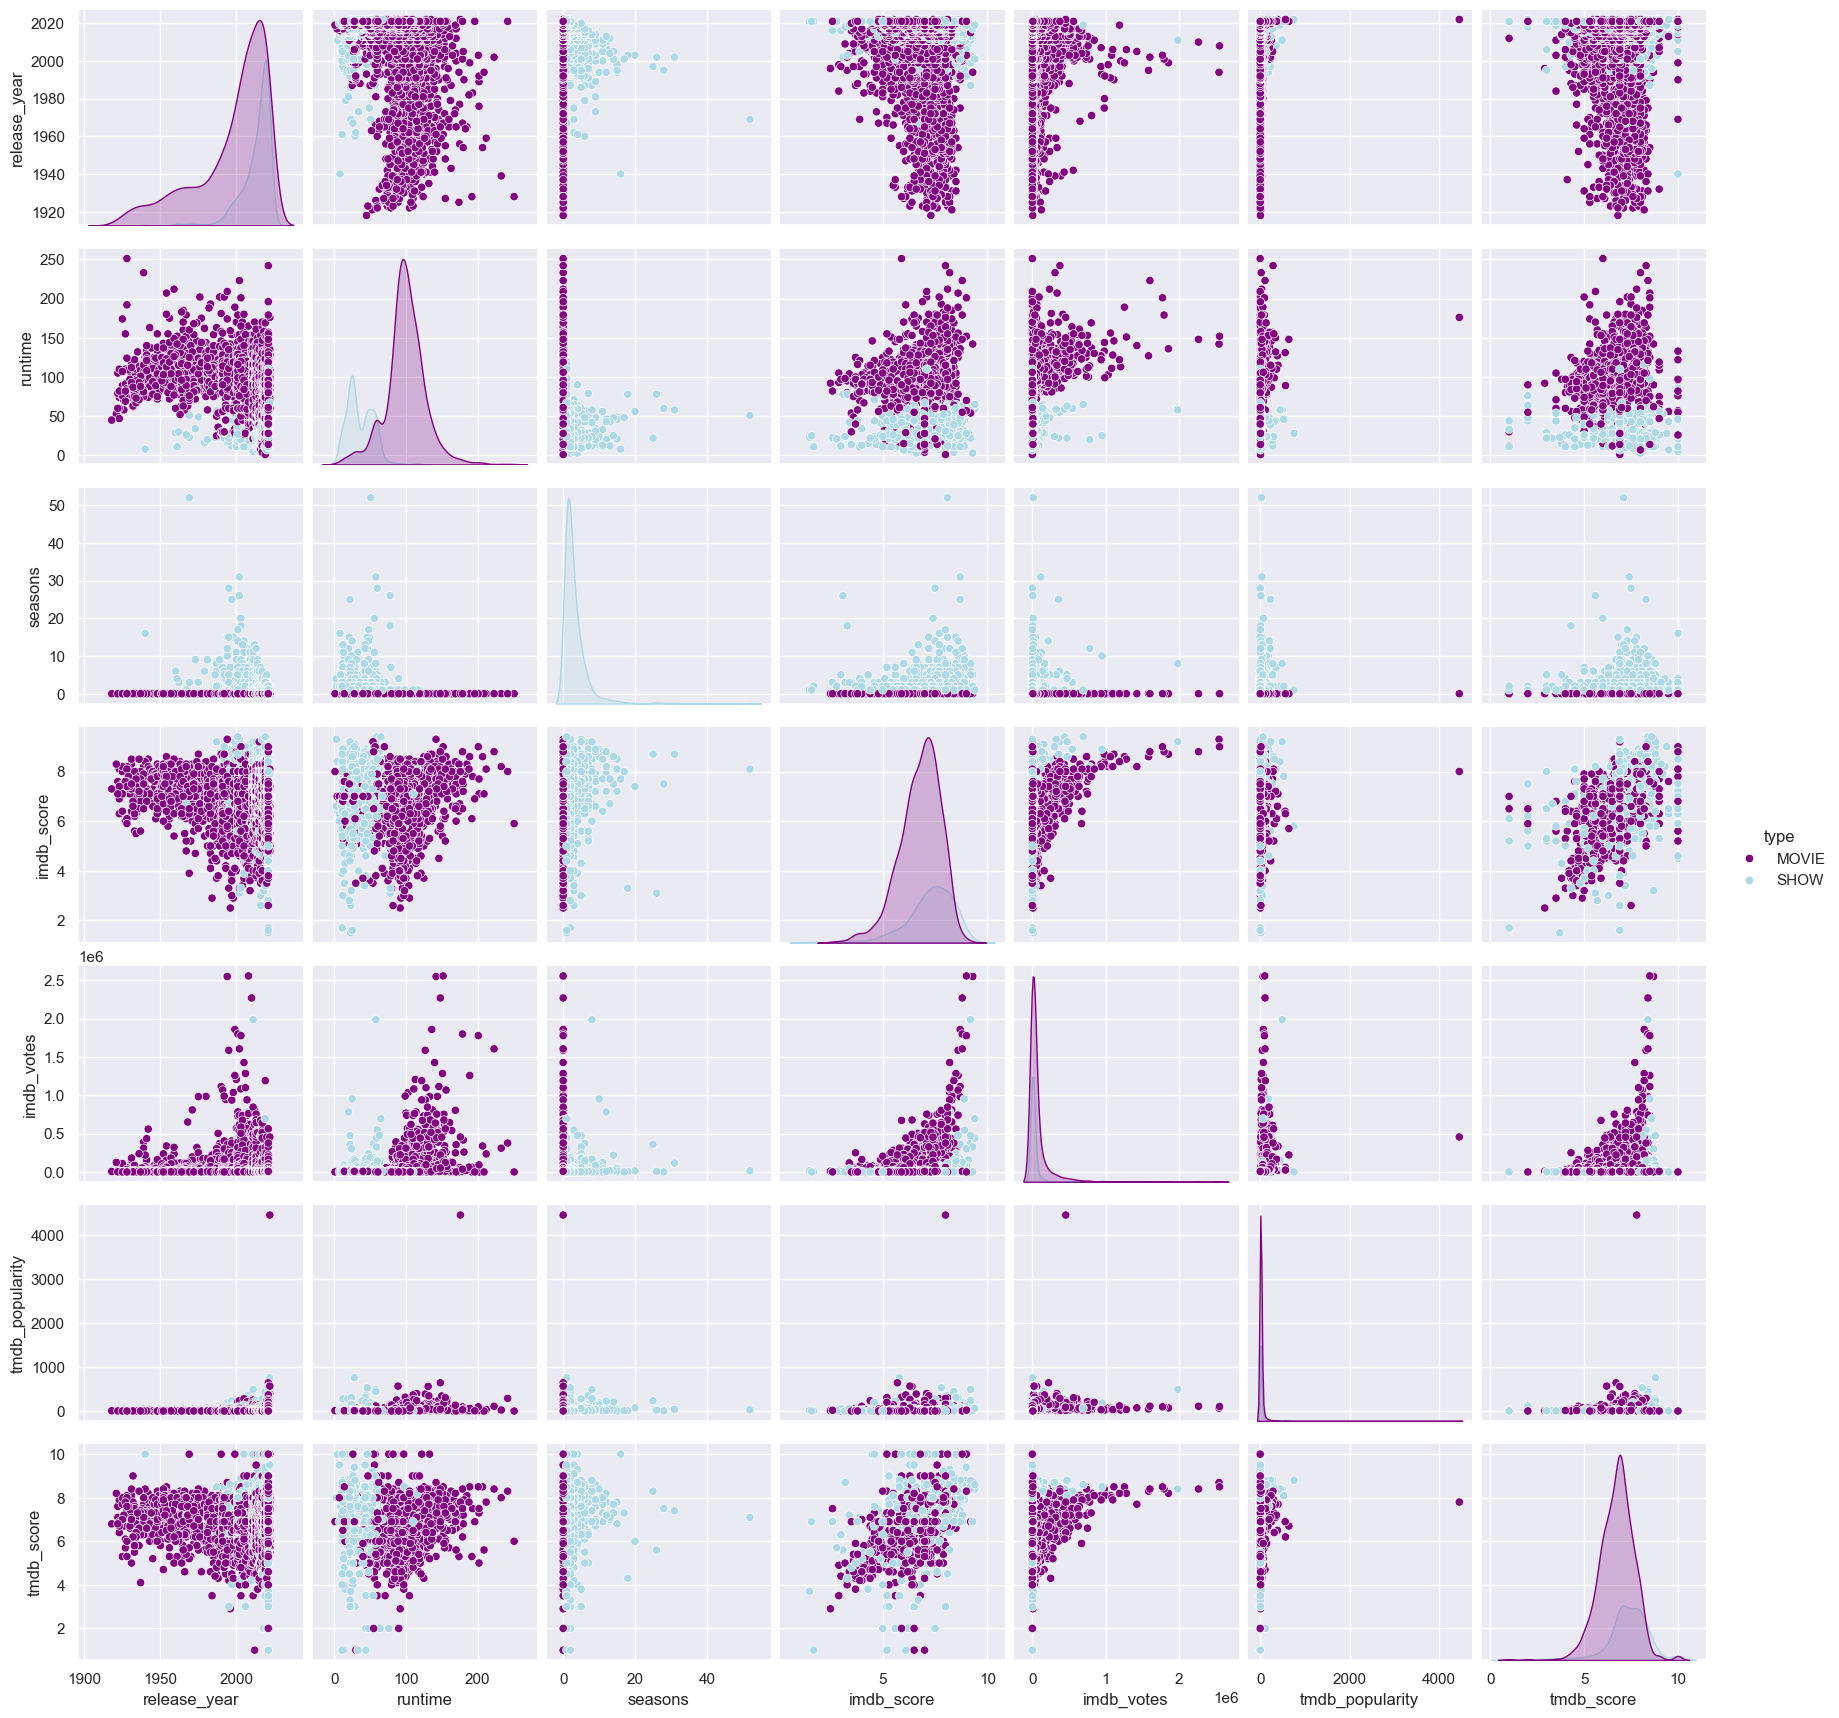

In [387]:
colors=['purple','lightblue']
sns.pairplot(data=df_title,hue='type',palette=colors)
plt.show()

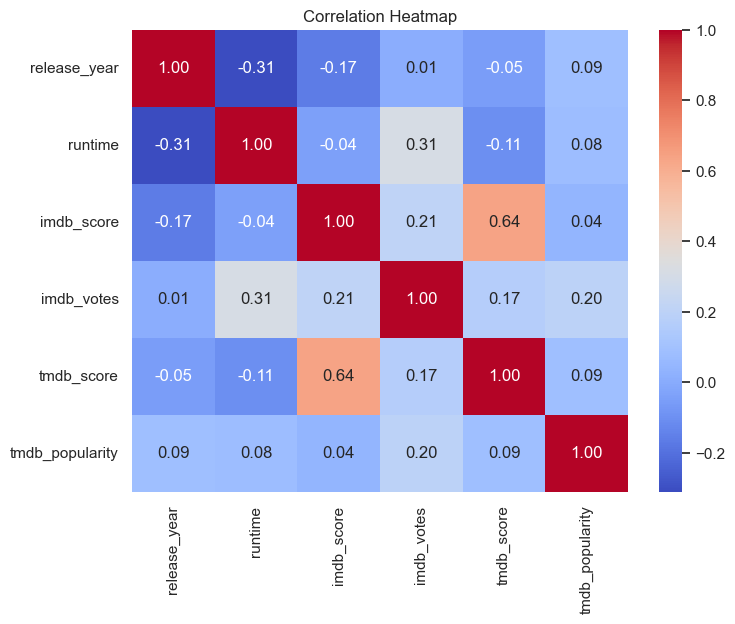

In [388]:
plt.figure(figsize=(8,6))

corr = df_title[['release_year','runtime','imdb_score',
                 'imdb_votes','tmdb_score','tmdb_popularity']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

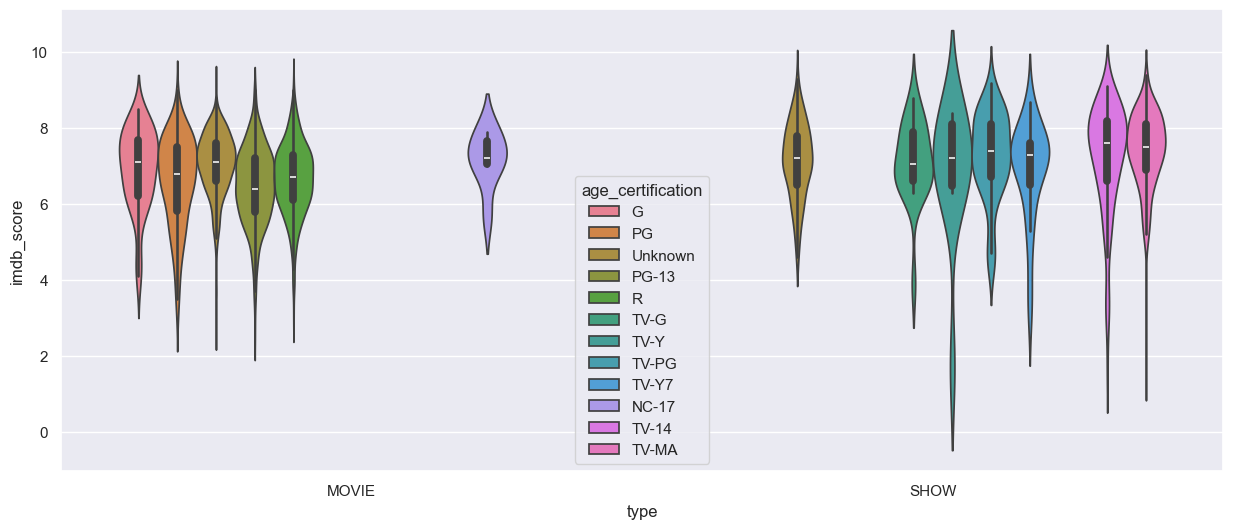

In [389]:
plt.figure(figsize=(15,6))
sns.violinplot(
    data=df_title,
    x='type',
    y='imdb_score',
    hue='age_certification',
)
plt.show()

## Feature Engineering

In [390]:
df_title['genres']

0                 [fantasy,  family]
1                            [drama]
2            [drama,  romance,  war]
3                 [thriller,  crime]
4       [thriller,  romance,  crime]
                    ...             
3287                       [reality]
3290                        [comedy]
3291                        [comedy]
3292                        [comedy]
3293                 [documentation]
Name: genres, Length: 2968, dtype: object

In [391]:
df_title['production_countries']

0       US
1       US
2       US
3       US
4       US
        ..
3287    US
3290    PA
3291      
3292      
3293    US
Name: production_countries, Length: 2968, dtype: object

In [394]:
print(type)

Axes(0.22375,0.11;0.5775x0.77)


In [395]:
del type

In [396]:
print(df_title["genres"].apply(type).value_counts())
#print(df_title["production_countries"].apply(type).value_counts())

genres
<class 'list'>    2968
Name: count, dtype: int64


In [398]:
df_title["genres"] = df_title["genres"].astype(str).str.lower().str.strip()
df_title["production_countries"] = df_title["production_countries"].astype(str).str.lower().str.strip()
df_title["description"] = df_title["description"].astype(str).str.lower().str.strip()

In [399]:
df_title[['title','description','genres']].head(2)

,title,description,genres
0,The Wizard of Oz,young dorothy finds herself in a magical world...,"['fantasy', ' family']"
1,Citizen Kane,"newspaper magnate, charles foster kane is take...",['drama']


In [400]:
df_title['content_features']=(df_title['genres'].fillna('')+ ' '+ df_title['description'].fillna(''))

In [401]:
df_title['content_features'].head(2)

0    ['fantasy', ' family'] young dorothy finds her...
1    ['drama'] newspaper magnate, charles foster ka...
Name: content_features, dtype: object

In [402]:
df_title['main_genre'] = df_title['genres'].str.split(',').str[0]

In [403]:
df_title['genre_count'] = df_title['genres'].str.count(',') + 1

In [404]:
def runtime_category(x):
    if x < 60:
        return "Short"
    elif x < 120:
        return "Medium"
    else:
        return "Long"

df_title['runtime_category'] = df_title['runtime'].apply(runtime_category)

In [405]:
df_title['country_count'] = df_title['production_countries'].str.count(',') + 1

In [406]:
df_title['rating_level'] = pd.cut(
    df_title['imdb_score'],
    bins=[0,5,7,8.5,10],
    labels=['Low','Average','High','Excellent']
)

In [407]:
df_title['content_age'] = 2026 - df_title['release_year']

In [408]:
df_title['decade'] = (df_title['release_year']//10)*10

In [409]:
df_title.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,...,tmdb_popularity,tmdb_score,content_features,main_genre,genre_count,runtime_category,country_count,rating_level,content_age,decade
0,tm155702,The Wizard of Oz,MOVIE,young dorothy finds herself in a magical world...,1939,G,102,"['fantasy', ' family']",us,0.0,...,41.442,7.6,"['fantasy', ' family'] young dorothy finds her...",['fantasy',2,Medium,1,High,87,1930
1,tm83648,Citizen Kane,MOVIE,"newspaper magnate, charles foster kane is take...",1941,PG,119,['drama'],us,0.0,...,14.383,8.0,"['drama'] newspaper magnate, charles foster ka...",['drama'],1,Medium,1,High,85,1940
2,tm77588,Casablanca,MOVIE,"in casablanca, morocco in december 1941, a cyn...",1942,PG,102,"['drama', ' romance', ' war']",us,0.0,...,20.087,8.2,"['drama', ' romance', ' war'] in casablanca, m...",['drama',3,Medium,1,High,84,1940
3,tm82363,The Big Sleep,MOVIE,private investigator philip marlowe is hired b...,1946,Unknown,116,"['thriller', ' crime']",us,0.0,...,12.911,7.7,"['thriller', ' crime'] private investigator ph...",['thriller',2,Medium,1,High,80,1940
4,tm84701,The Maltese Falcon,MOVIE,a private detective takes on a case that invol...,1941,Unknown,100,"['thriller', ' romance', ' crime']",us,0.0,...,12.788,7.8,"['thriller', ' romance', ' crime'] a private d...",['thriller',3,Medium,1,High,85,1940
